# Subsampling example — bootstrap methods

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/subsampling_example.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-22*

## Learning objectives

- Apply bootstrap subsampling to put confidence bounds on a sample mean when the underlying distribution is **not** normal and `N` is too small to invoke the Central Limit Theorem.
- Build the null distribution of sample means by repeatedly drawing random samples of the right size from the historical data.
- Compare bootstrap-based 95% bounds to the parametric (Normal) t-distribution bounds and see where they differ.


## The problem

This example is from the "Resampling: bootstrap" section of Chapter 1 of the lecture notes. It's drawn from a paper where the question was:

> You believe aerosols grow most when nearby geopotential heights are high. You composite the 500 hPa geopotential height on the 20 August days with measured aerosol formation/growth over Egbert, Canada, and find the mean is 5900 m. The long-term August mean at that station is 5886 m. **Are aerosol-growth days really associated with higher heights, or is this just sampling noise?**


## The approach

Two reasons we can't reach for a textbook test here:

1. We don't know the distribution of daily August 500 hPa heights — and as we'll see below, it isn't normal.
2. `N = 20` is too few samples to lean on the Central Limit Theorem.

But we have **lots** of historical August daily data. So we **subsample** it: draw 2,500 random 20-day samples from the historical record, compute the mean of each, and use those 2,500 means as the empirical null distribution of "20-day means under random chance." If our observed value of 5900 m falls outside the 95% bounds of that distribution, we have evidence that aerosol-growth days are special.


In [1]:
try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print(f"IN_COLAB = {IN_COLAB}")

IN_COLAB = False


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import scipy.stats as stats

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (6.0, 4.0)

rng = np.random.default_rng(17)

## Load the data

A MATLAB `.mat` file containing the daily August 500 hPa heights at the Egbert site.


In [3]:
if IN_COLAB:
    !pip install wget
    import wget

    filename = wget.download(
        "https://raw.githubusercontent.com/eabarnes1010/course_objective_analysis/main/data/subsampling_example_Z500_August.mat"
    )
else:
    filename = "../data/subsampling_example_Z500_August.mat"

DATA = sio.loadmat(filename)
X = DATA["X"][:, 0]
LAT = DATA["LAT"][0][0]
LONG = DATA["LONG"][0][0]

## Look at the data

Plot the histogram of all August daily Z500 values to see the shape of the underlying distribution.


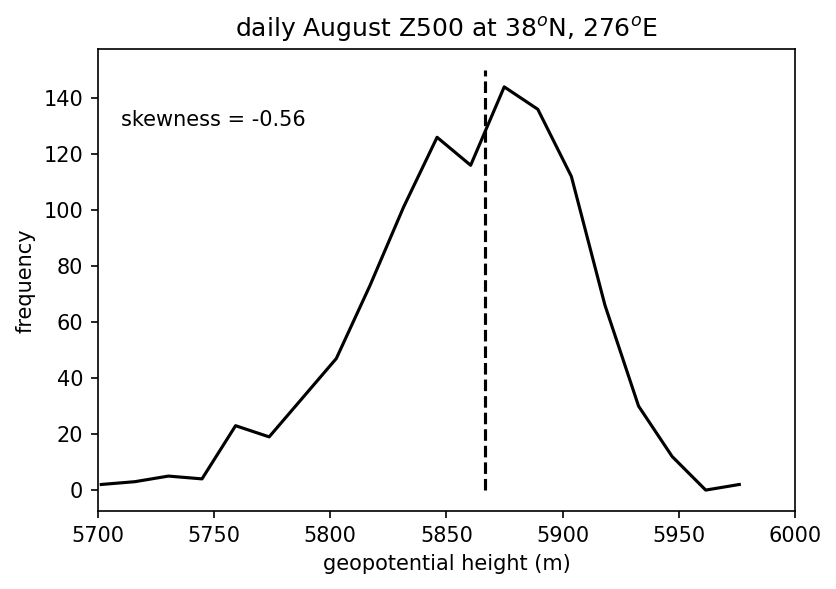

In [4]:
plt.figure()
h, bins = np.histogram(X, 20)
plt.plot(bins[:-1], h, color="black")

plt.xlabel("geopotential height (m)")
plt.ylabel("frequency")
plt.plot([np.mean(X), np.mean(X)], [0.0, 150], "--", color="black")
plt.title(f"daily August Z500 at {int(np.round(LAT))}$^o$N, {int(round(LONG))}$^o$E")

Z = (X - np.mean(X)) / np.std(X)
plt.text(5710, 130, f"skewness = {np.around(stats.skew(Z[:]), 2)}")
plt.xlim(5700, 6000)
plt.show()

The black curve is the daily August distribution and the dashed line is its mean. It is visibly skewed and far from Gaussian, so the CLT isn't safely usable at `N = 20`.


## Bootstrap subsampling

Our sample size is fixed by the question: the real composite had `N = 20` days, so each bootstrap draw also has 20 days.


In [5]:
sample_length = 20

Draw 2,500 random 20-day samples from the historical record, compute the mean of each, and save the means in `P`. (2,500 is plenty — could be 5,000 or 10,000; pick however many zeros you want, more iterations just sharpen the histogram.)


In [6]:
# Note: np.random.choice is another way to write this.
P = np.empty(2500)
for j, val in enumerate(P):
    ir = stats.randint.rvs(0, len(X) - 1, size=sample_length)
    P[j] = np.nanmean(X[ir])

## Visualize the bootstrap distribution

Plot the histogram of the 2,500 random 20-day sample means. Overlay the empirical 95% bounds (red dashed) and, for comparison, the parametric 95% bounds that a t-test would give you if you'd assumed the daily data were normal (blue dashed).


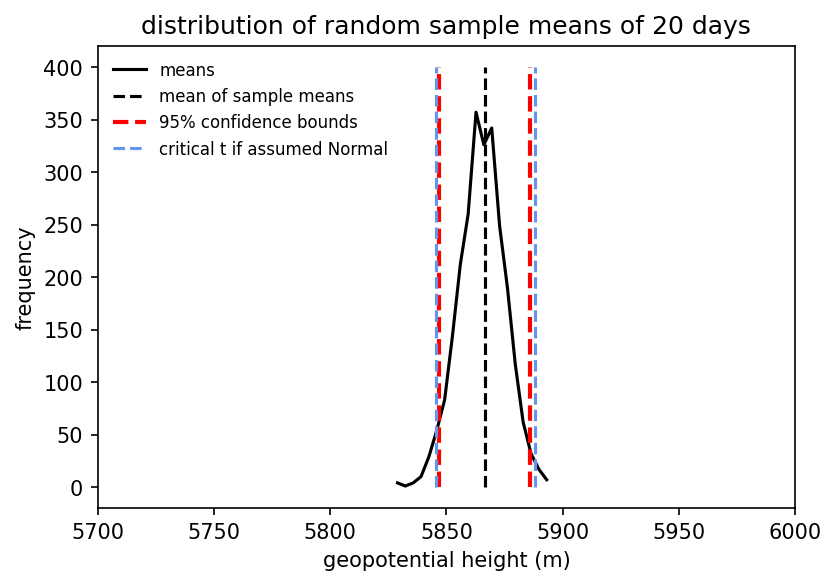

In [7]:
mp = 0.0

plt.figure()
h, bins = np.histogram(P - mp, 20)
plt.plot(bins[:-1], h, color="black", label="means")
plt.plot(
    (np.mean(X), np.mean(X)),
    (0.0, 400),
    "--",
    color="black",
    label="mean of sample means",
)

a1 = np.percentile(P - mp, 2.5)
a2 = np.percentile(P - mp, 100.0 - 2.5)
plt.plot(
    (a1, a1), (0, 400), "--", color="red", linewidth=2, label="95% confidence bounds"
)
plt.plot((a2, a2), (0, 400), "--", color="red", linewidth=2)

t_inc = (stats.t.ppf(0.975, sample_length - 1)) * np.std(X) / np.sqrt(sample_length - 1)
plt.plot(
    np.ones((2,)) * (np.mean(X) - t_inc),
    (0, 400),
    "--",
    color="cornflowerblue",
    label="critical t if assumed Normal",
)
plt.plot(np.ones((2,)) * (np.mean(X) + t_inc), (0, 400), "--", color="cornflowerblue")

plt.xlabel("geopotential height (m)")
plt.ylabel("frequency")
plt.legend(fontsize=8, frameon=False)
plt.title(f"distribution of random sample means of {sample_length} days")
plt.xlim(5700, 6000)
plt.show()

The black curve is the empirical null distribution of 20-day means under random sampling. Red dashed lines are the empirical 95% bounds; blue dashed lines are the bounds a t-test would give *if* we'd assumed normality. They aren't the same — the t-based bounds are noticeably wider.

Also note the bootstrap distribution is much narrower than the underlying daily distribution above. That's expected: averaging shrinks variability by `√N`.

Let's zoom in on where the action is.


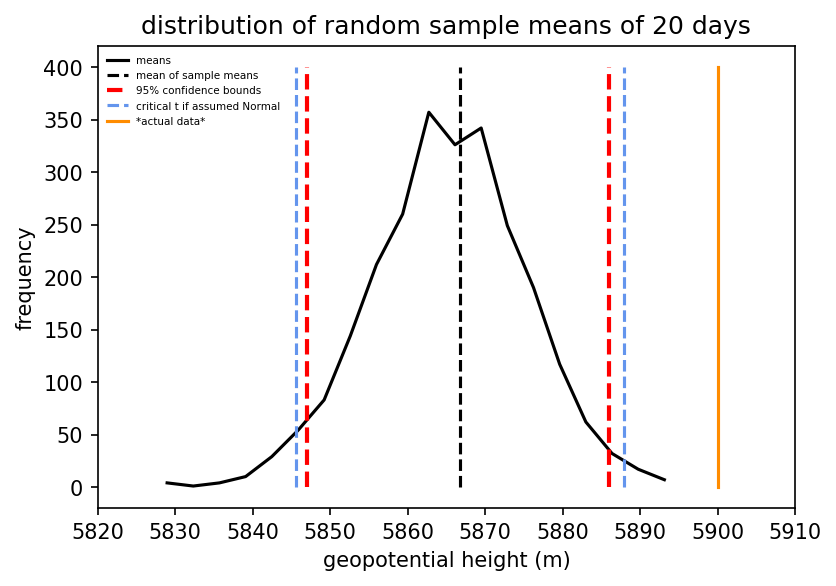

In [8]:
plt.figure()
h, bins = np.histogram(P - mp, 20)
plt.plot(bins[:-1], h, color="black", label="means")
plt.plot(
    (np.mean(X), np.mean(X)),
    (0.0, 400),
    "--",
    color="black",
    label="mean of sample means",
)
plt.plot(
    (a1, a1), (0, 400), "--", color="red", linewidth=2, label="95% confidence bounds"
)
plt.plot((a2, a2), (0, 400), "--", color="red", linewidth=2)
plt.plot(
    np.ones((2,)) * (np.mean(X) - t_inc),
    (0, 400),
    "--",
    color="cornflowerblue",
    label="critical t if assumed Normal",
)
plt.plot(np.ones((2,)) * (np.mean(X) + t_inc), (0, 400), "--", color="cornflowerblue")

plt.xlabel("geopotential height (m)")
plt.ylabel("frequency")
plt.title(f"distribution of random sample means of {sample_length} days")
plt.xlim(5820, 5910)

# Overlay the observed mean (5900 m) from the actual aerosol-growth composite.
plt.plot((5900, 5900), (0, 400), "-", color="darkorange", label="*actual data*")
plt.legend(fontsize=5, frameon=False)
plt.show()

## Conclusion

The orange line at 5900 m falls **outside** the empirical 95% bounds (red dashed), so we reject the null hypothesis that aerosol-growth days are statistically indistinguishable from random August days. The geopotential heights really do appear elevated on aerosol-growth days.

Notice that if we had naively used a t-test (assuming the daily data were normal), the 95% bounds would have been wider and 5900 m would have looked less impressive. When your data are clearly non-normal and `N` is small, bootstrapping the actual data gives you tighter, more honest bounds.


## Wrap-up

- Bootstrap subsampling builds an empirical null distribution by repeatedly drawing samples of the **same size** as your real sample from a data record.
- The sample size in each bootstrap draw is fixed by the question — only the number of iterations is yours to choose.
- For skewed, small-`N` problems the bootstrap can give tighter confidence bounds than a parametric (normal) test, and crucially it doesn't require you to assume a distribution you don't have.
